##Import Libraries

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

##Load Dataset

In [26]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\ML_project\student_placement_synthetic.csv")

df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [28]:
df.describe()

,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,68475.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750,17.308014
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618,2.601041
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,6.880000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,15.530000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000,17.250000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000,19.040000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000,28.330000


In [29]:
df.isnull().sum()

branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

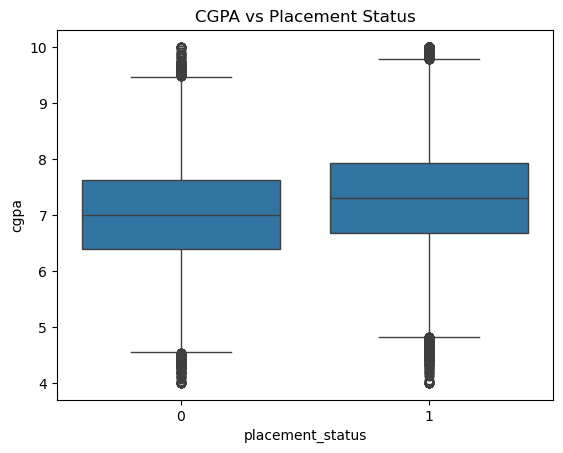

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="placement_status", y="cgpa", data=df)
plt.title("CGPA vs Placement Status")
plt.show()

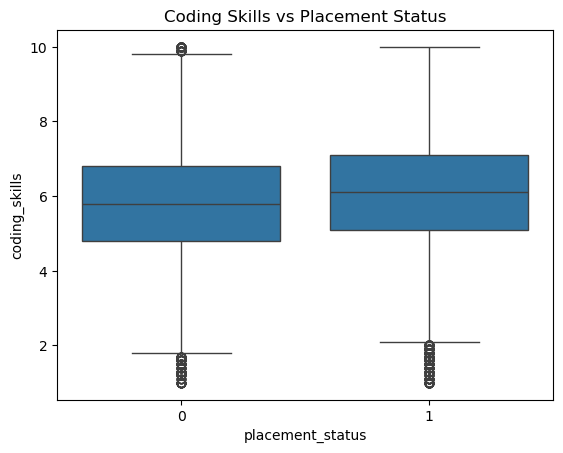

In [32]:
sns.boxplot(x="placement_status", y="coding_skills", data=df)
plt.title("Coding Skills vs Placement Status")
plt.show()

<Axes: xlabel='cgpa', ylabel='Count'>

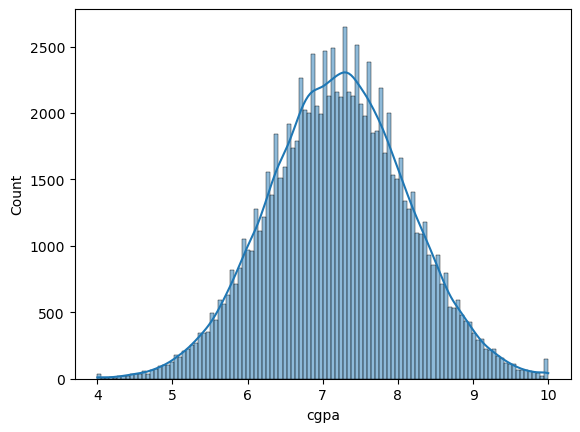

In [48]:
sns.histplot(df['cgpa'],kde=True)

<Axes: xlabel='placement_status', ylabel='count'>

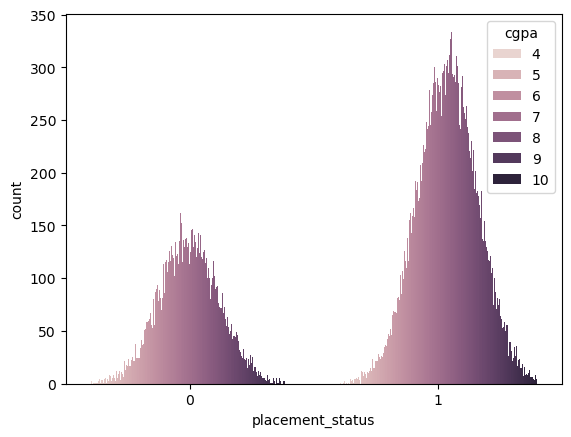

In [49]:
sns.countplot(data=df,x='placement_status',hue='cgpa')

<Axes: xlabel='cgpa', ylabel='dsa_score'>

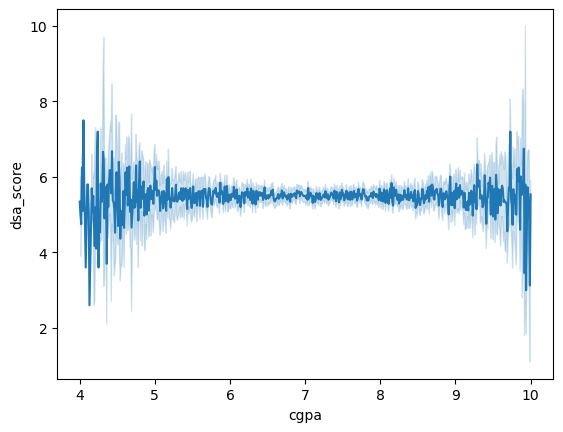

In [50]:
sns.lineplot(data=df,x='cgpa',y='dsa_score')

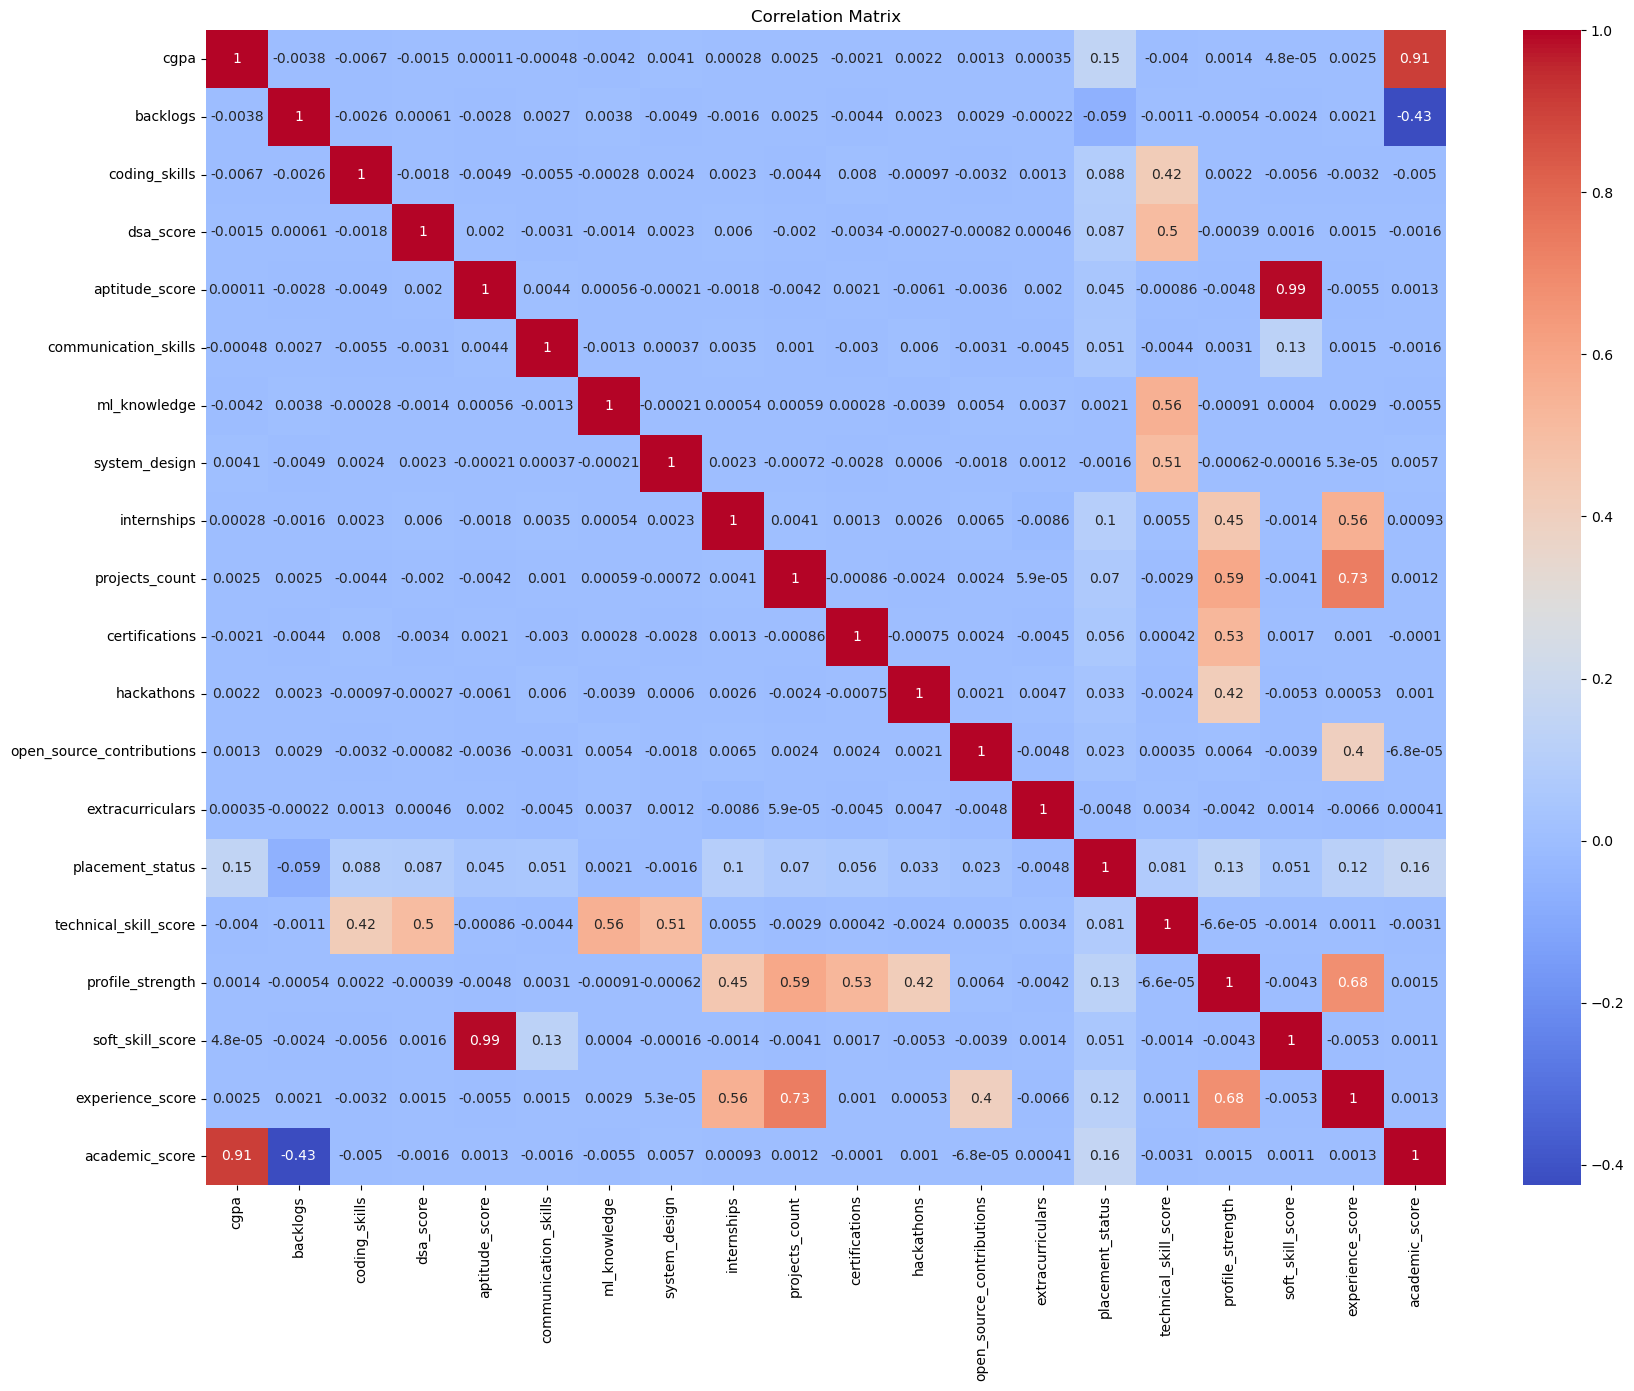

In [52]:
plt.figure(figsize=(20,15))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

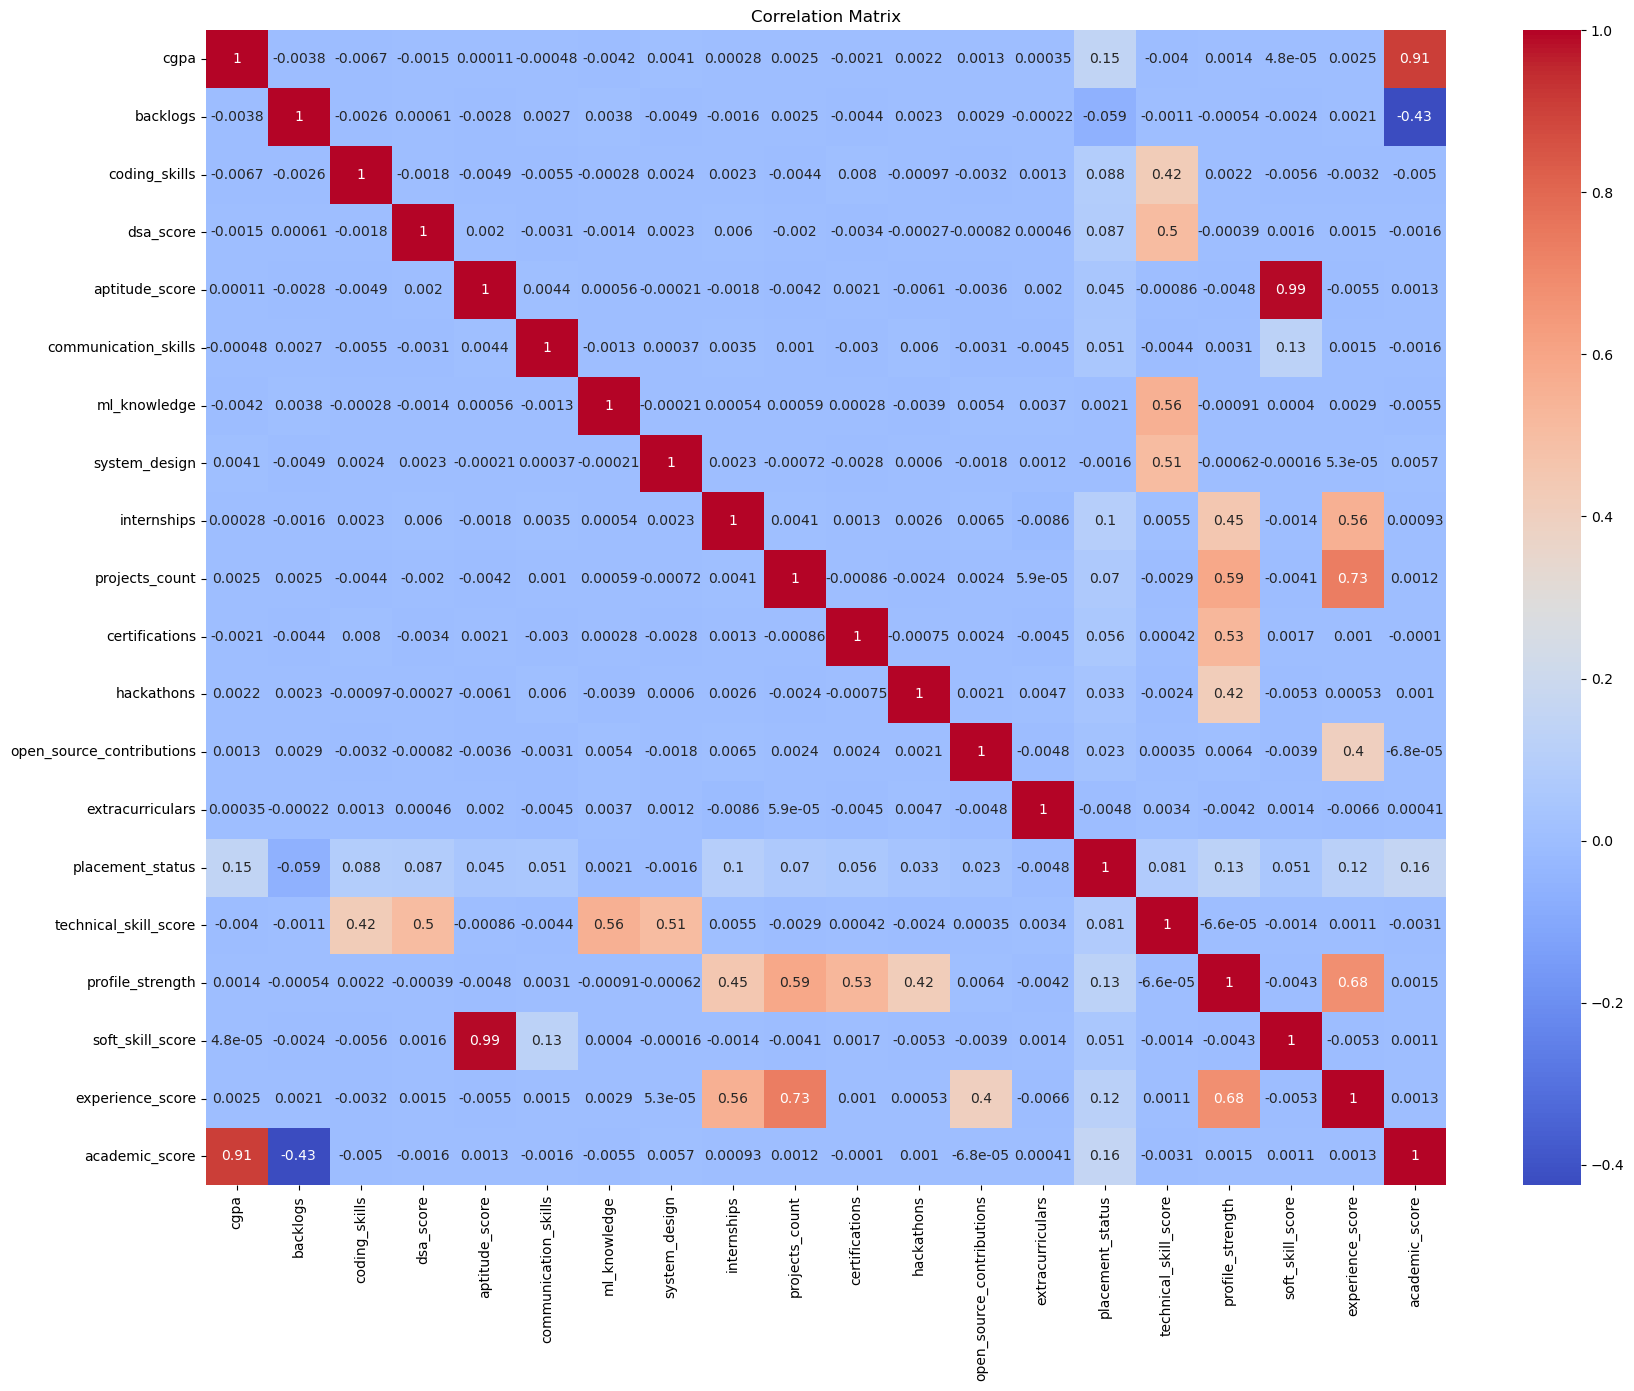

In [53]:
plt.figure(figsize=(20,15))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [33]:
df.corr(numeric_only=True)["placement_status"].sort_values(ascending=False)

placement_status             1.000000
cgpa                         0.148932
internships                  0.099967
coding_skills                0.087657
dsa_score                    0.086594
projects_count               0.069900
certifications               0.055636
communication_skills         0.051034
aptitude_score               0.045146
hackathons                   0.033315
open_source_contributions    0.022723
ml_knowledge                 0.002097
system_design               -0.001583
extracurriculars            -0.004807
backlogs                    -0.058815
salary_package_lpa                NaN
Name: placement_status, dtype: float64

In [34]:
# Technical skill score
df["technical_skill_score"] = (
 df["coding_skills"] +
 df["dsa_score"] +
 df["ml_knowledge"] +
 df["system_design"]
) / 4


# Profile strength
df["profile_strength"] = (
 df["projects_count"] +
 df["internships"] +
 df["certifications"] +
 df["hackathons"]
)


# Soft skills
df["soft_skill_score"] = (
 df["communication_skills"] +
 df["aptitude_score"]
) / 2


# Experience score
df["experience_score"] = (
 df["internships"] +
 df["open_source_contributions"] +
 df["projects_count"]
)


# Academic strength
df["academic_score"] = (
 df["cgpa"] -
 df["backlogs"] * 0.5
)

In [35]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

##Drop salary column (many missing values)

In [36]:
df = df.drop("salary_package_lpa", axis=1)

### One-Hot Encoding for categorical columns

In [37]:
df = pd.get_dummies(df, columns=["branch","college_tier"], drop_first=True)

##Define Features and Target

In [38]:
X = df.drop("placement_status", axis=1)
y = df["placement_status"]

##Split Train/Test

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [40]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

train_pred = log_model.predict(X_train)
test_pred = log_model.predict(X_test)

print("Logistic Regression")

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

print(classification_report(y_test, test_pred))

Logistic Regression
Training Accuracy: 0.7005125
Testing Accuracy: 0.69915
              precision    recall  f1-score   support

           0       0.57      0.20      0.30      6335
           1       0.72      0.93      0.81     13665

    accuracy                           0.70     20000
   macro avg       0.64      0.57      0.55     20000
weighted avg       0.67      0.70      0.65     20000



In [42]:
log_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_balanced.fit(X_train, y_train)

train_pred = log_balanced.predict(X_train)
test_pred = log_balanced.predict(X_test)

print("Logistic Balanced")

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

print(classification_report(y_test, test_pred))

Logistic Balanced
Training Accuracy: 0.6289875
Testing Accuracy: 0.6318
              precision    recall  f1-score   support

           0       0.44      0.65      0.53      6335
           1       0.79      0.62      0.70     13665

    accuracy                           0.63     20000
   macro avg       0.62      0.64      0.61     20000
weighted avg       0.68      0.63      0.64     20000



In [43]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

print("Random Forest")

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

print(classification_report(y_test, test_pred))

Random Forest
Training Accuracy: 0.7222
Testing Accuracy: 0.69505
              precision    recall  f1-score   support

           0       0.60      0.12      0.19      6335
           1       0.70      0.96      0.81     13665

    accuracy                           0.70     20000
   macro avg       0.65      0.54      0.50     20000
weighted avg       0.67      0.70      0.62     20000



In [44]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

train_pred = xgb_model.predict(X_train)
test_pred = xgb_model.predict(X_test)

print("XGBoost")

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

print(classification_report(y_test, test_pred))

XGBoost
Training Accuracy: 0.7334375
Testing Accuracy: 0.69535
              precision    recall  f1-score   support

           0       0.55      0.21      0.30      6335
           1       0.71      0.92      0.81     13665

    accuracy                           0.70     20000
   macro avg       0.63      0.56      0.55     20000
weighted avg       0.66      0.70      0.65     20000



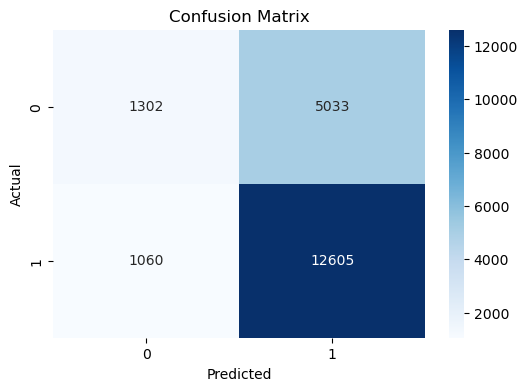

In [45]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [46]:
models = ["Logistic","Logistic Balanced","Random Forest","XGBoost"]

train_acc = []
test_acc = []

models_list = [
    log_model,
    log_balanced,
    rf_model,
    xgb_model
]

for model in models_list:

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))

results = pd.DataFrame({
    "Model":models,
    "Train Accuracy":train_acc,
    "Test Accuracy":test_acc
})

print(results)

               Model  Train Accuracy  Test Accuracy
0           Logistic        0.700512        0.69915
1  Logistic Balanced        0.628988        0.63180
2      Random Forest        0.722200        0.69505
3            XGBoost        0.733437        0.69535


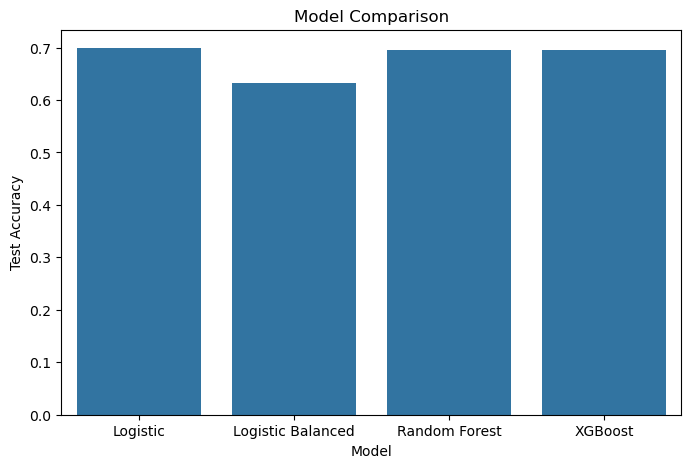

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Test Accuracy",
    data=results
)

plt.title("Model Comparison")
plt.show()